### Load Data

conda activate preprocess_data

In [3]:
import glob
import sys
import os
import re
import numpy as np
import tifffile as tiff
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random
from send2trash import send2trash

folder_path = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\virtual_staining_processing_inference_functions"
sys.path.append(folder_path)
from processing_functions import *


## Compute Mean and STD of images and normalize first. 

In [29]:
root = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT"
train_crop_root = os.path.join(root, 'train', 'crypts', 'crop')
test_crop_root = os.path.join(root, 'test', 'crypts', 'crop')

print("Number of train stacks: ", len(glob.glob(os.path.join(train_crop_root, '*.tif'))))
print("Number of test stacks: ", len(glob.glob(os.path.join(test_crop_root, '*.tif'))))
#compute_mean_std_and_save(train_crop_root, pattern='*.tif')

Number of train stacks:  18
Number of test stacks:  3


## Break up BIT and MUSE images into training patches. 

### Load Data

#### Process: 
    1. Flatfield correct with sigma = 50 
    2. Normalize and case image to uint16
    3. Median filter with size 3 kernel
    4. Normalize 16bit to 8bit with 1% and 99.9%, min and max, respectively. 


In [1]:
import cv2
def preprocess_training_flatfield_contrast_enhance_data(output_path, stack_path):
    BIT_stacks = glob.glob(stack_path + r'\*.tif')
    save_path = os.path.join(output_path, 'preprocessed')
    os.makedirs(save_path, exist_ok=True)
    clahe = cv2.createCLAHE(clipLimit=clahe_clipLimit, tileGridSize=(clahe_tileGridSize, clahe_tileGridSize))
    for i, stack_name in enumerate(BIT_stacks):
        print(f"Processing stack {i+1} of {len(BIT_stacks)}")
        img_stack = tiff.imread(stack_name)
        img_stack = np.array(img_stack, dtype=img_stack.dtype)
        print(f"Original stack shape: {img_stack.shape}, dtype: {img_stack.dtype}")

        enhanced_stack = np.zeros(img_stack.shape, dtype=np.uint8)



        for i, img in enumerate(img_stack):

            img = flatfield_correct(img, sigma=50)

            # Cast image to uint16 after normalization for CLAHE
            BIT_img = cv2.normalize(img, None, 0, 65535, cv2.NORM_MINMAX).astype(np.uint16)

            # Median Filter to reduce granularity
            

            # Apply CLAHE
            #BIT_img = clahe.apply(BIT_img)

            medfilter_kernel_size = 3
            BIT_img = cv2.medianBlur(BIT_img, medfilter_kernel_size)

            BIT_img = normalize_16bit_to_8bit(BIT_img)

            # Min Max normalization


            enhanced_stack[i] = BIT_img

        # Save the enhanced stack
        base_name = os.path.basename(stack_name)
        print(enhanced_stack.dtype)
        #img_save_path = os.path.join(save_path, f"medfilt_enhanced_clahegrid={clahe_tileGridSize}_cliplimit={clahe_clipLimit}_{base_name}")
        img_save_path = os.path.join(save_path, base_name)
        tiff.imwrite(img_save_path, enhanced_stack)

    print(save_path)

import numpy as np
import cv2  # Optional, for image writing or visualization

def normalize_16bit_to_8bit(image_16bit: np.ndarray, percentiles = (1, 99.9)) -> np.ndarray:
    """
    Normalize a 16-bit image to 8-bit using the 1st and 99th percentiles.

    Args:
        image_16bit (np.ndarray): Input 16-bit image (dtype=np.uint16)

    Returns:
        np.ndarray: Output 8-bit image (dtype=np.uint8)
    """
    assert image_16bit.dtype == np.uint16, "Input must be a 16-bit image"

    # Compute 1st and 99th percentiles
    p1 = np.percentile(image_16bit, percentiles[0])
    p99 = np.percentile(image_16bit, percentiles[1])

    # Clip the image to [p1, p99] range
    clipped = np.clip(image_16bit, p1, p99)

    # Normalize to [0, 255]
    normalized = (clipped - p1) / (p99 - p1) * 255.0

    # Convert to uint8
    image_8bit = normalized.astype(np.uint8)

    return image_8bit




In [ ]:

preprocess_training_flatfield_contrast_enhance_data(test_crop_root, test_crop_root)
preprocess_training_flatfield_contrast_enhance_data(train_crop_root, train_crop_root)

NameError: name 'glob' is not defined

In [13]:



def compute_optimal_stride(img_shape, patch_size, overlap_percent=0.10):
    """
    Computes the optimal stride (x, y) for given image shape and patch size
    to achieve the desired overlap and ensure full coverage.

    Args:
        img_shape (tuple): (height, width) of the image
        patch_size (int): size of the square patch
        overlap_percent (float): desired fractional overlap (e.g., 0.1 for 10%)

    Returns:
        tuple: (x_stride, y_stride)
    """
    import math

    h, w = img_shape

    # Initial stride from overlap percentage
    stride = int(patch_size * (1 - overlap_percent))
    stride = max(1, stride)

    # Compute number of patches along height and width (round up to ensure coverage)
    n_patches_y = math.ceil((h - patch_size) / stride) + 1
    n_patches_x = math.ceil((w - patch_size) / stride) + 1

    # Recompute stride so that last patch ends exactly at (h - patch_size) and (w - patch_size)
    if n_patches_y > 1:
        y_stride = (h - patch_size) // (n_patches_y - 1)
    else:
        y_stride = 0

    if n_patches_x > 1:
        x_stride = (w - patch_size) // (n_patches_x - 1)
    else:
        x_stride = 0

    return y_stride, x_stride






def flatfield_correct(image, sigma=50):
    """
    Perform flat-field correction on an image using Gaussian smoothing.
    
    Parameters:
        image: np.ndarray
            Input image (grayscale or multi-channel).
        sigma: float
            Gaussian blur sigma for estimating the background illumination.
    
    Returns:
        corrected: np.ndarray
            Flat-field corrected image as float32.
    """
    image = np.ascontiguousarray(image, dtype=np.float32)
    #image = np.asarray(image).astype(np.float32) # ensure image is a numpy array. 
    blurred = cv2.GaussianBlur(image, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
    corrected = image / (blurred + 1e-8)  # avoid division by zero
    return corrected

import numpy as np

def normalize_to_uint8_percentile(img: np.ndarray, percentile = 100) -> np.ndarray:
    """
    Normalize a grayscale image using min-max normalization with clipping at the 95th percentile,
    then scale to [0, 255] and convert to uint8.

    Parameters:
        img (np.ndarray): Input grayscale image (2D or 3D if single-channel).

    Returns:
        np.ndarray: Normalized image as uint8 in [0, 255].
    """
    img = img.astype(np.float32)
    p_min = np.min(img)
    p_max = np.percentile(img, percentile)

    img_clipped = np.clip(img, p_min, p_max)
    img_norm = (img_clipped - p_min) / (p_max - p_min + 1e-8)  # avoid divide-by-zero
    img_uint8 = (img_norm * 255).astype(np.uint8)

    return img_uint8

def break_image_into_training_patches_new(base_name, img_num, img, output_folder, patch_size,
                                      x_step_size, y_step_size):
    """
    Break an image into patches and save metadata for reconstruction. Supports custom x and y step sizes.

    Parameters:
        img_type (str): Identifier for the image type
        img_num (int or str): Image number
        img_path (str): Path to the input image
        img (PIL.Image or np.ndarray): Loaded image
        output_folder (str): Folder to save patches and metadata
        patch_size (int): Size of each square patch (patch is patch_size x patch_size)
        x_step_size (int): Horizontal stride between patches
        y_step_size (int): Vertical stride between patches
        n_random (int): Number of additional random patches to extract
        seed (int): Random seed for reproducibility
    """
    os.makedirs(output_folder, exist_ok=True)
    

    img_np = np.array(img)
    if img_np.ndim == 3 and img_np.shape[2] > 1:
        raise ValueError("This function currently only supports single-channel (grayscale) images.")
    
    h, w = img_np.shape[:2]
    patch_counter = 1
    patch_info_list = []
    taken_coords = set()
    name_no_ext = os.path.splitext(os.path.basename(base_name))[0]

    # Step 1: Regular grid patches
    for y in range(0, h - patch_size + 1, y_step_size):
        for x in range(0, w - patch_size + 1, x_step_size):
            patch = img_np[y:y+patch_size, x:x+patch_size]
            patch_name = f"{name_no_ext}_img={img_num}_P={patch_counter}.tif"
            patch_path = os.path.join(output_folder, patch_name)
            #patch = normalize_to_uint8_percentile(patch)
            Image.fromarray(patch).save(patch_path)
            patch_info_list.append(f"{patch_name},{x},{y},{patch_size},{patch_size}")
            taken_coords.add((x, y))
            patch_counter += 1
        

    # Step 3: Save metadata file
    metadata_file = os.path.join(output_folder, f"{name_no_ext}_patches_stitch_metadata.txt")
    with open(metadata_file, "w") as f:
        f.write(f"# Original image: {base_name}\n")
        f.write(f"# Original size: width={w}, height={h}\n")
        f.write(f"# Patch size: {patch_size}\n")
        f.write(f"# Step size: x={x_step_size}, y={y_step_size}\n")
        f.write(f"# Channels: 1\n")
        f.write("# Format: patch_filename,x,y,width,height\n")
        for info in patch_info_list:
            f.write(info + "\n")

    print(f"Saved {patch_counter-1} patches and metadata to {metadata_file}")



def process_training_data(output_path, BIT_stacks, patch_size_h, patch_size_w):
    for i, stack_name in enumerate(BIT_stacks):
        print(f"Processing stack {i+1} of {len(BIT_stacks)}")
        img_stack = tiff.imread(stack_name)
        img_stack = np.array(img_stack, dtype=img_stack.dtype)
        print(f"Original stack shape: {img_stack.shape}, dtype: {img_stack.dtype}")


        for i, img in enumerate(img_stack):
  
            img_shape = img.shape
            #patch_size = (patch_size_h, patch_size_w)  # Example patch size
            stride_h, stride_w = compute_optimal_stride(img_shape, patch_size_w)

            print(f"Optimal Stride: {stride_h}x{stride_w}")

            break_image_into_training_patches_new(stack_name, i, img, output_path, patch_size_h,
                                      stride_w, stride_h)


import glob
import os
import shutil

def copy_txt_files(output_path, output_folder):
    """
    Copies all .txt files from `output_path` to `output_folder`.

    Args:
        output_path (str): Source folder path containing .txt files.
        output_folder (str): Destination folder path for copied files.
    """
    # Make sure destination exists
    os.makedirs(output_folder, exist_ok=True)

    # Find all .txt files in output_path
    BIT_meta_data_stacks_train = glob.glob(os.path.join(output_path, '*.txt'))

    # Copy each file to the output folder
    for txt_file in BIT_meta_data_stacks_train:
        filename = os.path.basename(txt_file)
        destination = os.path.join(output_folder, filename)
        shutil.copy(txt_file, destination)
        print(f"Copied: {filename} → {output_folder}")


### Process Single Stack

Original stack shape: (32, 1302, 1866), dtype: uint8
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt


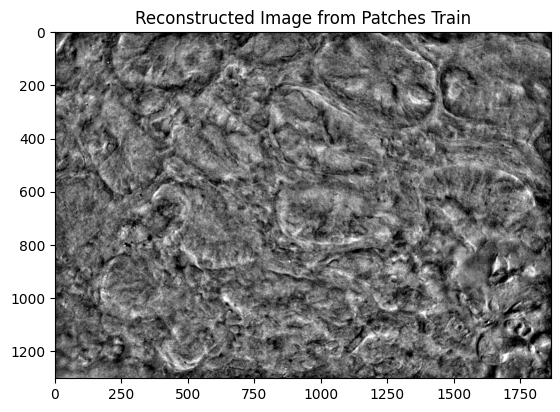

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

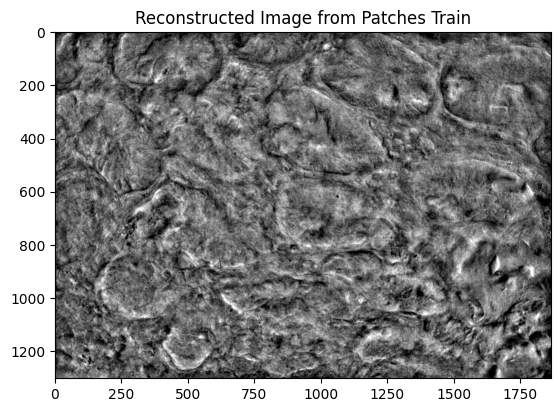

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

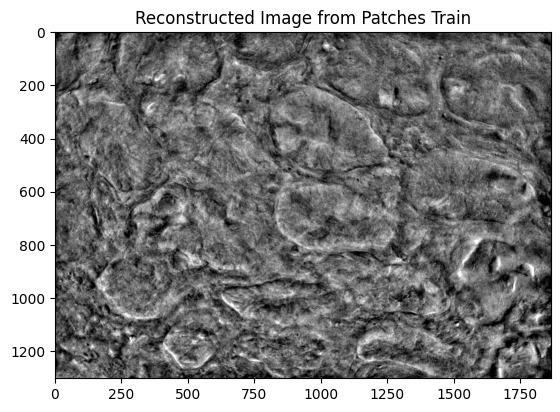

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

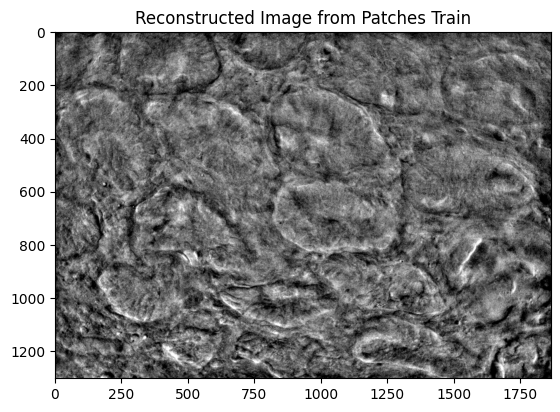

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

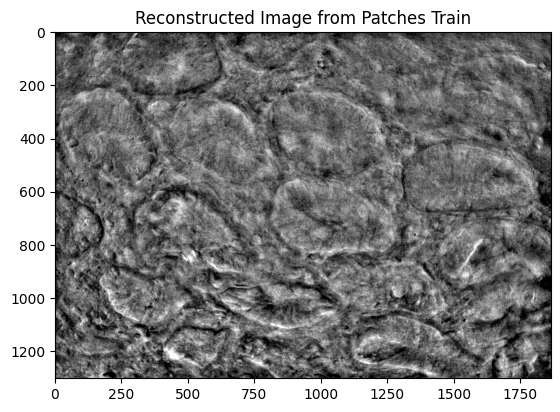

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

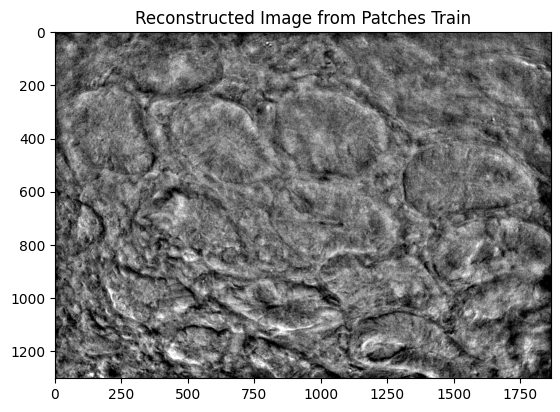

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_t

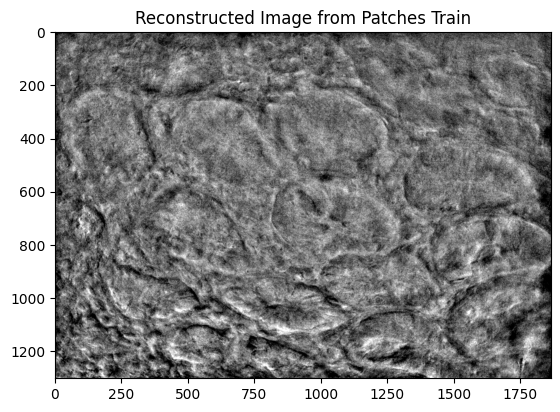

Optimal Stride: 395x451
Saved 12 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_patches_stitch_metadata.txt
✅ Saved inverted image: C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches_inverted\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_img=0_P=1.tif
✅ Saved inverted image: C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\patches_inverted\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61_img=0_P=10.tif
✅ Saved inverted image: C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed\crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61\pa

In [14]:
test_stack = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\test\crypts\crop\preprocessed"
stack_name = r'crypts_Duodenum_IM0012_cropped_BIT_40X_frame30-61'
output_path = os.path.join(test_stack, stack_name, 'patches')
stack_name_path = os.path.join(test_stack, stack_name + ".tif")

patch_size_h = 512
patch_size_w = 512
img_stack = tiff.imread(stack_name_path)
img_stack = np.array(img_stack, dtype=img_stack.dtype)
print(f"Original stack shape: {img_stack.shape}, dtype: {img_stack.dtype}")


for i, img in enumerate(img_stack):

    img_shape = img.shape
    #patch_size = (patch_size_h, patch_size_w)  # Example patch size
    stride_h, stride_w = compute_optimal_stride(img_shape, patch_size_w)

    print(f"Optimal Stride: {stride_h}x{stride_w}")

    break_image_into_training_patches_new(stack_name, i, img, output_path, patch_size_h,
                                stride_w, stride_h)
    
    if i%5 == 0:
        BIT_meta_data_stacks_train = glob.glob(output_path + r'\*.txt')
        reconstructed_BIT_img_train = reconstruct_image_from_patches(BIT_meta_data_stacks_train[0], output_path)
        plt.imshow(reconstructed_BIT_img_train, cmap='gray')
        plt.title("Reconstructed Image from Patches Train")       
        plt.show()

# Invert the Patches. 
inverted_path = os.path.join(test_stack, stack_name, 'patches_inverted')
invert_images_to_new_folder(output_path, inverted_path)

# Combine into RGB for Training. 
output_test_path = os.path.join(test_stack, stack_name, 'testA')
combine_trios_to_rgb(output_path, inverted_path, output_path, output_test_path)

# Move .txt recon file to testA folder and inverted folder
copy_txt_files(output_path, inverted_path)
copy_txt_files(output_path, output_test_path)


### Process Multiple Stacks 

In [ ]:
root = r"C:\Users\durrlab-asong\Desktop\virtual_staining_training_data"
train_root = os.path.join(root, 'duodenum', 'BIT', 'train', 'crypts', 'crop', 'preprocessed')
output_path_train = os.path.join(train_root, 'patches')
BIT_stacks_train = glob.glob(train_root + r'\*.tif')
print(len(BIT_stacks_train))
print(BIT_stacks_train[0])
process_training_data(output_path_train, BIT_stacks_train, 512, 512)

test_root = os.path.join(root, 'duodenum', 'BIT', 'test', 'crypts', 'crop', 'preprocessed')
output_path_test = os.path.join(test_root, 'patches')
BIT_stacks_test = glob.glob(test_root + r'\*.tif')
print(len(BIT_stacks_test))
print(BIT_stacks_test[0])
process_training_data(output_path_test, BIT_stacks_test, 512, 512)  



18
C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\train\crypts\crop\preprocessed\crypts_Duodenum_IM0001_cropped_BIT_40x_frame20-50_crop3.tif
Processing stack 1 of 18
Original stack shape: (31, 858, 1200), dtype: uint8
Optimal Stride: 346x344
Saved 6 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\train\crypts\crop\preprocessed\patches\crypts_Duodenum_IM0001_cropped_BIT_40x_frame20-50_crop3_patches_stitch_metadata.txt
Optimal Stride: 346x344
Saved 6 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\train\crypts\crop\preprocessed\patches\crypts_Duodenum_IM0001_cropped_BIT_40x_frame20-50_crop3_patches_stitch_metadata.txt
Optimal Stride: 346x344
Saved 6 patches and metadata to C:\Users\durrlab-asong\Desktop\virtual_staining_training_data\duodenum\BIT\train\crypts\crop\preprocessed\patches\crypts_Duodenum_IM0001_cropped_BIT_40x_frame20-50_crop3_patches_stitch_metad

NameError: name 'reconstruct_image_from_patches_preprocess' is not defined

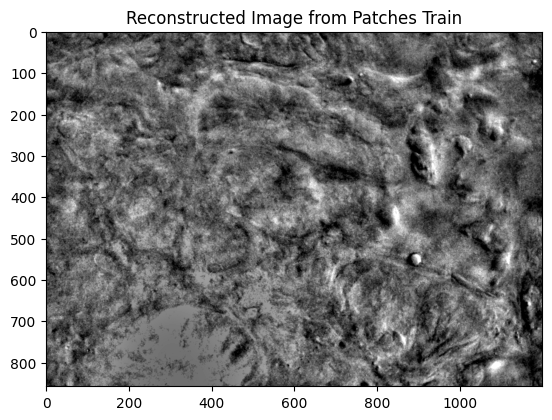

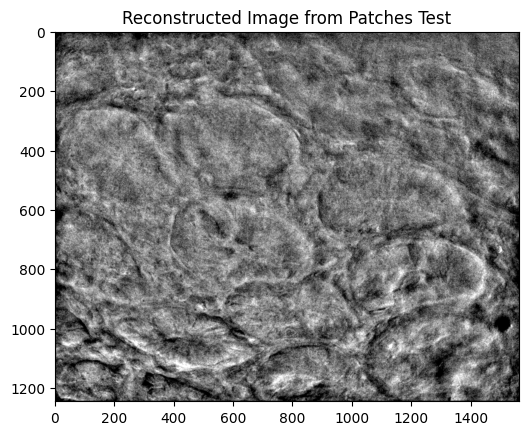

In [9]:

BIT_meta_data_stacks_train = glob.glob(output_path_train + r'\*.txt')
reconstructed_BIT_img_train = reconstruct_image_from_patches(BIT_meta_data_stacks_train[0], output_path_train)
plt.imshow(reconstructed_BIT_img_train, cmap='gray')
plt.title("Reconstructed Image from Patches Train")       
plt.show()

BIT_meta_data_stacks_test = glob.glob(output_path_test + r'\*.txt')
reconstructed_BIT_img_test = reconstruct_image_from_patches(BIT_meta_data_stacks_test[0], output_path_test)
plt.imshow(reconstructed_BIT_img_test, cmap='gray')
plt.title("Reconstructed Image from Patches Test")       
plt.show()